# House Price Prediction 

---

## Project Overview

This notebook builds a **regression pipeline** to predict residential house sale prices using the [Kaggle Ames Housing dataset](https://www.kaggle.com/c/house-prices-advanced-regression-techniques).

### Objectives
- Perform exploratory data analysis (EDA) with rich visualisations
- Engineer features and handle missing data systematically
- Train and **tune** three candidate models: Linear Regression, Random Forest, and XGBoost
- Evaluate each model rigorously using multiple metrics
- Select the best model based on RMSE and R²

### Dataset
| Split | File | Rows (approx.) |
|-------|------|----------------|
| Train | `train.csv` | 1,460 |
| Test  | `test.csv`  | 1,459 |

### Target Variable
`SalePrice` — the final sale price of the house in USD.

---


## 1. Environment Setup

Install and import all required libraries.


In [8]:
%pip install xgboost --quiet



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [9]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor

# Global plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13, 'axes.labelsize': 11})

print("✅ All libraries loaded successfully")


✅ All libraries loaded successfully


---
## 2. Data Loading & Initial Exploration

Load the train and test CSV files and take an initial look at the combined dataset.


In [10]:
data1 = pd.read_csv('data/train.csv')
data2 = pd.read_csv('data/test.csv')
data  = pd.concat([data1, data2], ignore_index=True)

print(f"Train rows : {len(data1):,}  |  Test rows: {len(data2):,}  |  Combined: {len(data):,}")
print(f"Columns    : {data.shape[1]}")
data.head()


Train rows : 1,460  |  Test rows: 1,459  |  Combined: 2,919
Columns    : 81


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500.0
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500.0
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500.0
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000.0
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000.0


In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2919 entries, 0 to 2918
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             2919 non-null   int64  
 1   MSSubClass     2919 non-null   int64  
 2   MSZoning       2915 non-null   object 
 3   LotFrontage    2433 non-null   float64
 4   LotArea        2919 non-null   int64  
 5   Street         2919 non-null   object 
 6   Alley          198 non-null    object 
 7   LotShape       2919 non-null   object 
 8   LandContour    2919 non-null   object 
 9   Utilities      2917 non-null   object 
 10  LotConfig      2919 non-null   object 
 11  LandSlope      2919 non-null   object 
 12  Neighborhood   2919 non-null   object 
 13  Condition1     2919 non-null   object 
 14  Condition2     2919 non-null   object 
 15  BldgType       2919 non-null   object 
 16  HouseStyle     2919 non-null   object 
 17  OverallQual    2919 non-null   int64  
 18  OverallC

In [12]:
data.describe().T.style.background_gradient(cmap='Blues', subset=['mean','std'])

,count,mean,std,min,25%,50%,75%,max
Id,2919.000000,1460.000000,842.787043,1.000000,730.500000,1460.000000,2189.500000,2919.000000
MSSubClass,2919.000000,57.137718,42.517628,20.000000,20.000000,50.000000,70.000000,190.000000
LotFrontage,2433.000000,69.305795,23.344905,21.000000,59.000000,68.000000,80.000000,313.000000
LotArea,2919.000000,10168.114080,7886.996359,1300.000000,7478.000000,9453.000000,11570.000000,215245.000000
OverallQual,2919.000000,6.089072,1.409947,1.000000,5.000000,6.000000,7.000000,10.000000
OverallCond,2919.000000,5.564577,1.113131,1.000000,5.000000,5.000000,6.000000,9.000000
YearBuilt,2919.000000,1971.312778,30.291442,1872.000000,1953.500000,1973.000000,2001.000000,2010.000000
YearRemodAdd,2919.000000,1984.264474,20.894344,1950.000000,1965.000000,1993.000000,2004.000000,2010.000000
MasVnrArea,2896.000000,102.201312,179.334253,0.000000,0.000000,0.000000,164.000000,1600.000000
BsmtFinSF1,2918.000000,441.423235,455.610826,0.000000,0.000000,368.500000,733.000000,5644.000000


---
## 3. Missing Value Analysis & Imputation

Identify and handle nulls before modelling.


In [13]:
# Summarise missing data
missing = (data.isnull().sum() / len(data) * 100).sort_values(ascending=False)
missing = missing[missing > 0]
print(f"Columns with missing values: {len(missing)}")
missing.head(20)


Columns with missing values: 35


PoolQC          99.657417
MiscFeature     96.402878
Alley           93.216855
Fence           80.438506
MasVnrType      60.500171
SalePrice       49.982871
FireplaceQu     48.646797
LotFrontage     16.649538
GarageCond       5.447071
GarageYrBlt      5.447071
GarageFinish     5.447071
GarageQual       5.447071
GarageType       5.378554
BsmtExposure     2.809181
BsmtCond         2.809181
BsmtQual         2.774923
BsmtFinType2     2.740665
BsmtFinType1     2.706406
MasVnrArea       0.787941
MSZoning         0.137033
dtype: float64

In [14]:
# Impute missing values
train_rows = data.index < len(data1)
numeric_cols     = data.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = data.select_dtypes(include=[object]).columns.tolist()

for col in numeric_cols:
    if col == 'SalePrice':
        continue
    if data[col].isnull().any():
        data[col].fillna(data[col].median(), inplace=True)

for col in categorical_cols:
    if data[col].isnull().any():
        data[col].fillna(data[col].mode()[0], inplace=True)

if data.loc[train_rows, 'SalePrice'].isnull().any():
    data.loc[train_rows, 'SalePrice'] = data.loc[train_rows, 'SalePrice'].fillna(
        data.loc[train_rows, 'SalePrice'].mean()
    )

print(f"Remaining nulls after imputation: {data.isnull().sum().sum()}")


Remaining nulls after imputation: 1459


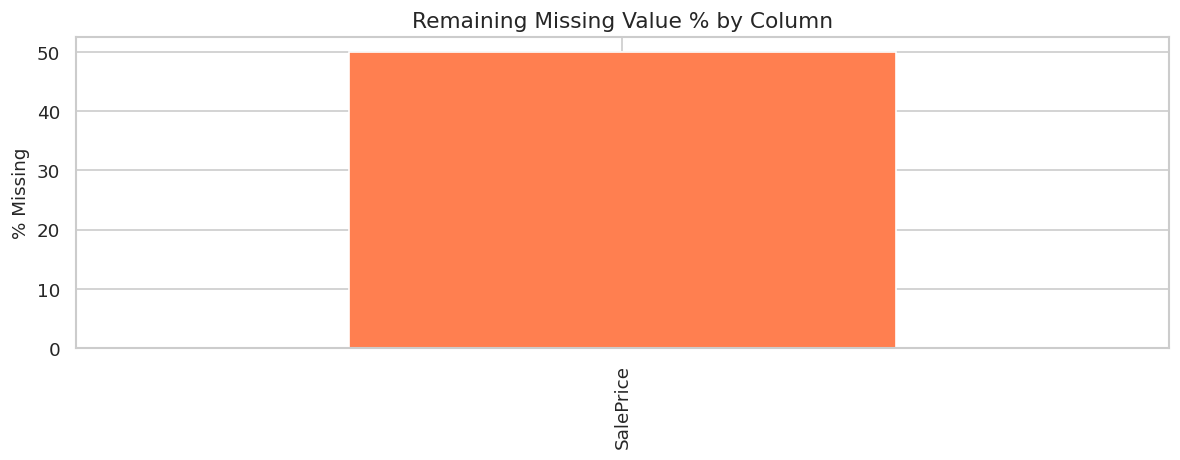

In [15]:
# Visualise missing-data percentage before/after (post-imputation check)
fig, ax = plt.subplots(figsize=(10, 4))
missing_pct = data.isnull().sum() / len(data) * 100
missing_pct_sorted = missing_pct[missing_pct > 0].sort_values(ascending=False)
if len(missing_pct_sorted) == 0:
    ax.text(0.5, 0.5, 'No Missing Values Remaining ✅', ha='center', va='center',
            fontsize=14, transform=ax.transAxes)
else:
    missing_pct_sorted.plot(kind='bar', ax=ax, color='coral')
    ax.set_title('Remaining Missing Value % by Column')
    ax.set_ylabel('% Missing')
ax.set_xlabel('')
plt.tight_layout()
plt.show()


---
## 4. Exploratory Data Analysis (EDA)

Understand the distribution of the target, feature correlations, and key drivers of sale price.


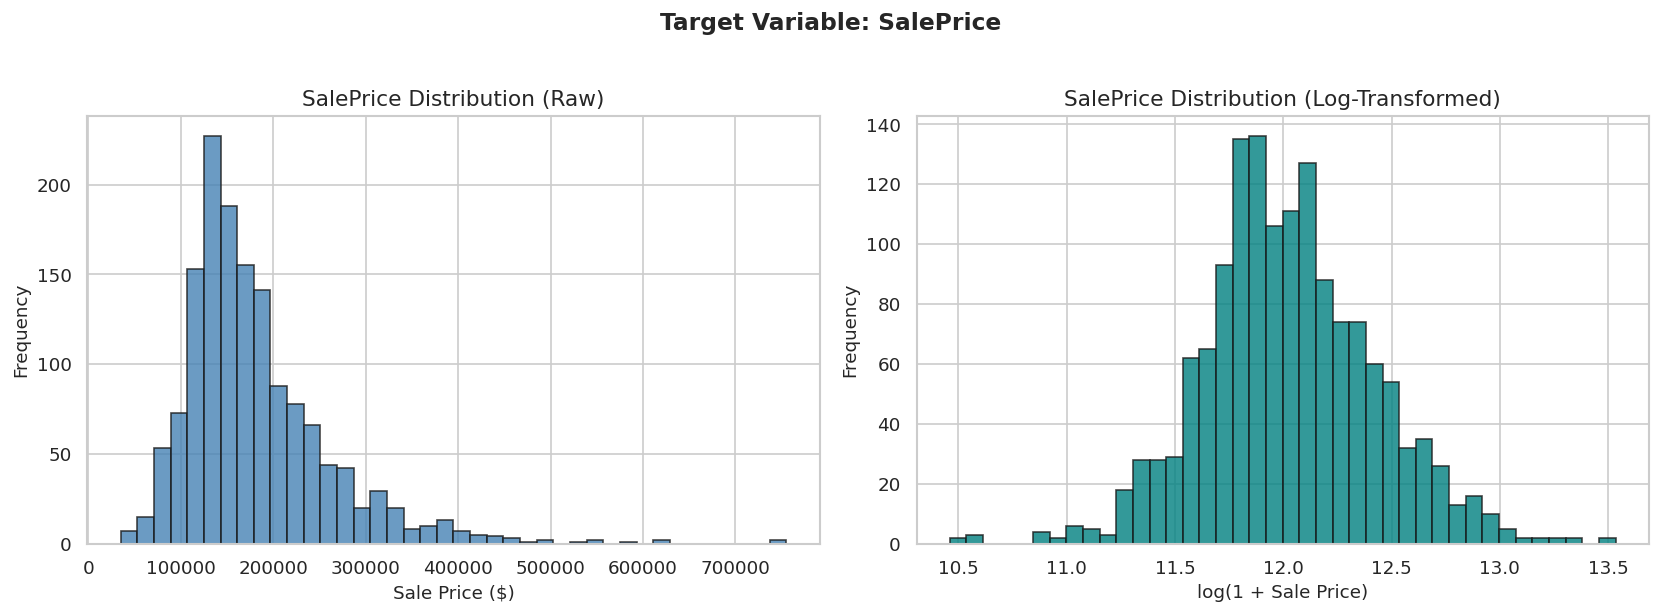

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw distribution
axes[0].hist(data['SalePrice'].dropna(), bins=40, edgecolor='k', color='steelblue', alpha=0.8)
axes[0].set_title('SalePrice Distribution (Raw)')
axes[0].set_xlabel('Sale Price ($)')
axes[0].set_ylabel('Frequency')

# Log-transformed distribution
axes[1].hist(np.log1p(data['SalePrice'].dropna()), bins=40, edgecolor='k', color='teal', alpha=0.8)
axes[1].set_title('SalePrice Distribution (Log-Transformed)')
axes[1].set_xlabel('log(1 + Sale Price)')
axes[1].set_ylabel('Frequency')

plt.suptitle('Target Variable: SalePrice', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


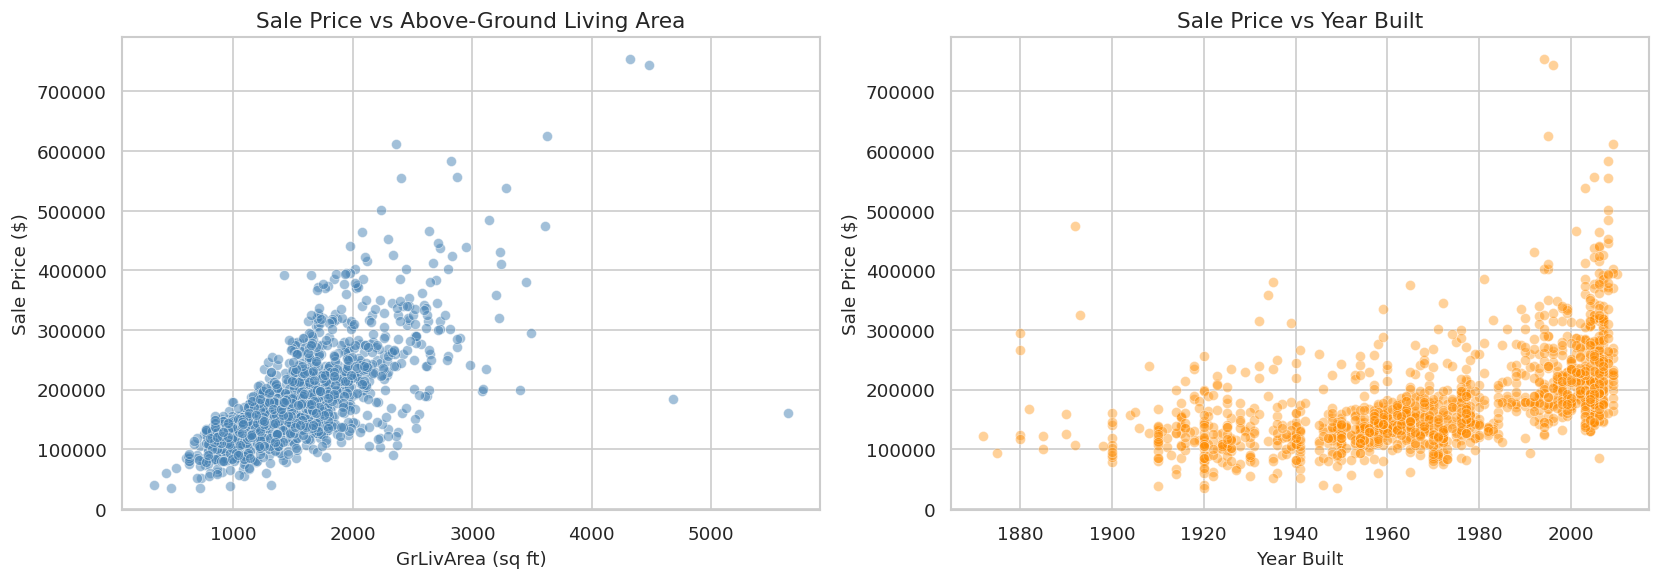

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(x='GrLivArea', y='SalePrice', data=data, alpha=0.5, ax=axes[0], color='steelblue')
axes[0].set_title('Sale Price vs Above-Ground Living Area')
axes[0].set_xlabel('GrLivArea (sq ft)')
axes[0].set_ylabel('Sale Price ($)')

sns.scatterplot(x='YearBuilt', y='SalePrice', data=data, alpha=0.4, ax=axes[1], color='darkorange')
axes[1].set_title('Sale Price vs Year Built')
axes[1].set_xlabel('Year Built')
axes[1].set_ylabel('Sale Price ($)')

plt.tight_layout()
plt.show()


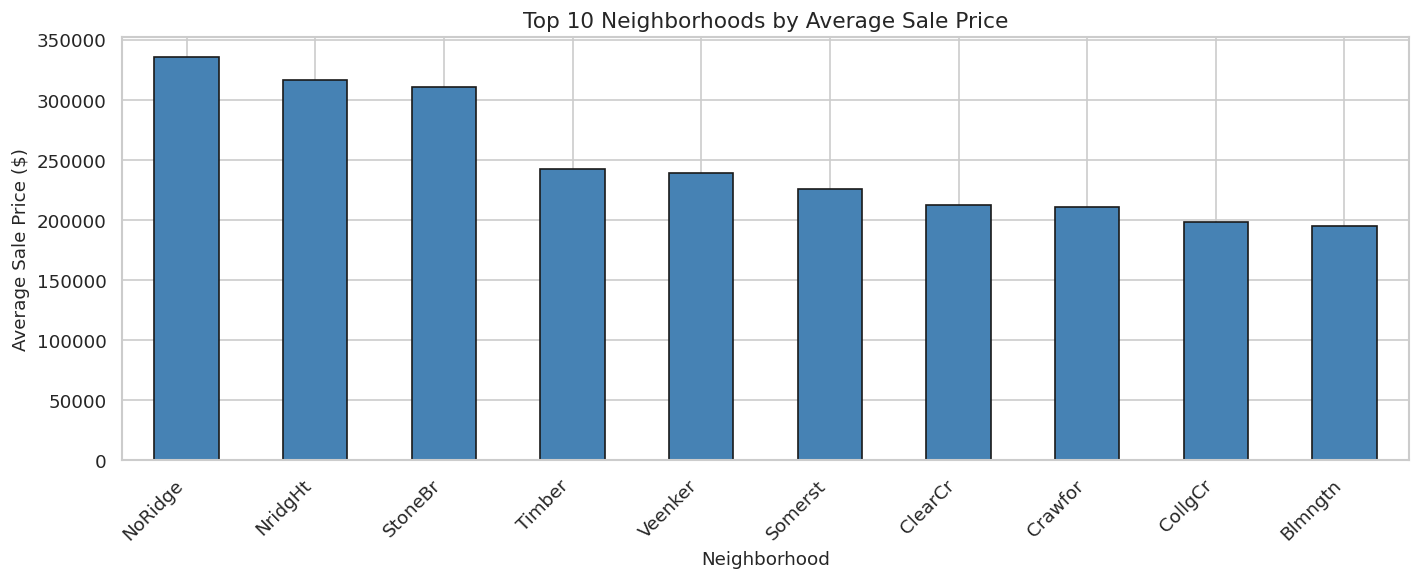

In [18]:
# Top 10 neighbourhoods by average sale price
fig, ax = plt.subplots(figsize=(12, 5))
neigh_price = data.groupby('Neighborhood')['SalePrice'].mean().sort_values(ascending=False)
neigh_price.head(10).plot(kind='bar', ax=ax, color='steelblue', edgecolor='k')
ax.set_title('Top 10 Neighborhoods by Average Sale Price')
ax.set_xlabel('Neighborhood')
ax.set_ylabel('Average Sale Price ($)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()


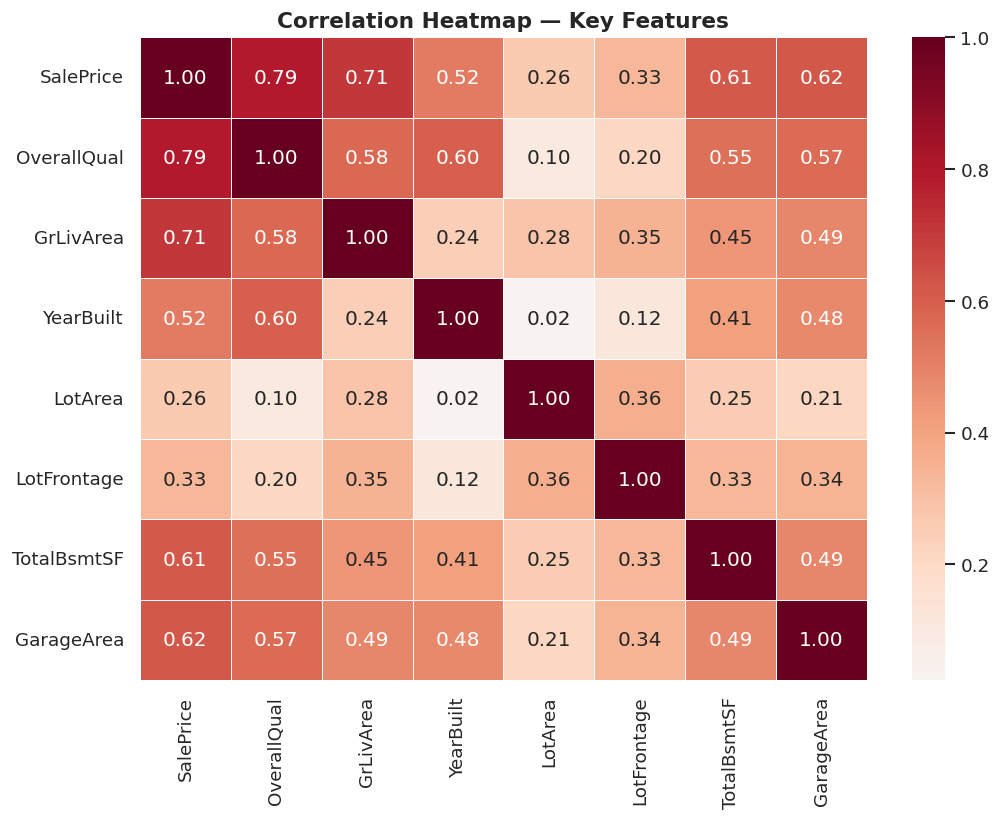

In [19]:
# Correlation heatmap for key numeric features
key_cols = ['SalePrice', 'OverallQual', 'GrLivArea', 'YearBuilt',
            'LotArea', 'LotFrontage', 'TotalBsmtSF', 'GarageArea']
corr = data[key_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0, fmt='.2f',
            linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap — Key Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


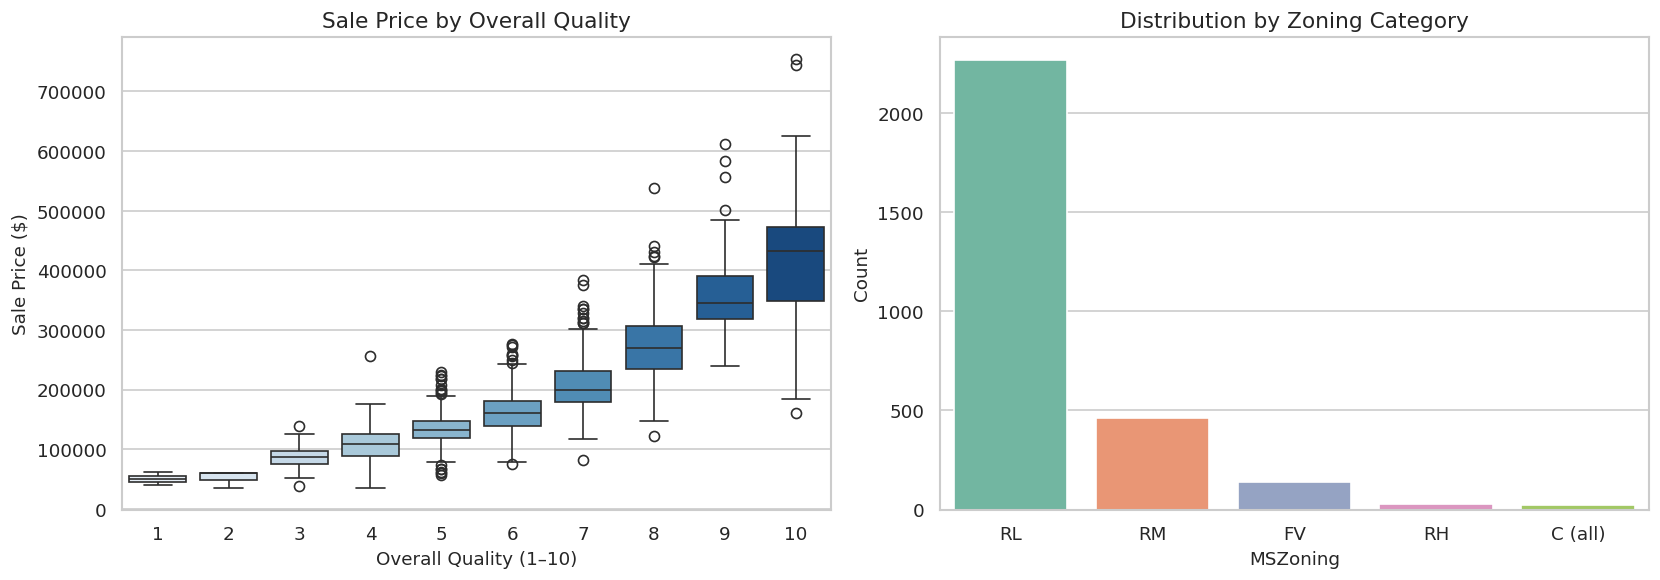

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall quality vs price
sns.boxplot(x='OverallQual', y='SalePrice', data=data, ax=axes[0], palette='Blues')
axes[0].set_title('Sale Price by Overall Quality')
axes[0].set_xlabel('Overall Quality (1–10)')
axes[0].set_ylabel('Sale Price ($)')

# Zoning distribution
order = data['MSZoning'].value_counts().index
sns.countplot(x='MSZoning', data=data, order=order, ax=axes[1], palette='Set2')
axes[1].set_title('Distribution by Zoning Category')
axes[1].set_xlabel('MSZoning')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()


---
## 5. Feature Engineering & Preprocessing

Select high-impact features, encode categoricals, and prepare train/test splits.


In [21]:
# Drop rows without a target (test split rows)
train_data = data.dropna(subset=['SalePrice']).copy()

y = train_data['SalePrice']

feature_columns = [
    'MSSubClass', 'MSZoning', 'LotArea', 'Neighborhood', 'OverallQual',
    'OverallCond', 'YearBuilt', 'GrLivArea', 'FullBath', 'BedroomAbvGr',
    'TotRmsAbvGrd', 'GarageCars', 'GarageArea'
]

X = train_data[feature_columns]
X = pd.get_dummies(X, drop_first=True)
X = X.fillna(X.mean())

print(f"Feature matrix shape: {X.shape}")
print(f"Target shape        : {y.shape}")


Feature matrix shape: (1460, 39)
Target shape        : (1460,)


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train size: {X_train.shape[0]:,}  |  Test size: {X_test.shape[0]:,}")


Train size: 1,168  |  Test size: 292


---
## 6. Model Training & Hyperparameter Tuning

We train three models and tune the best performers with `GridSearchCV`.

| Model | Type | Notes |
|-------|------|-------|
| Linear Regression | Baseline | Simple, interpretable |
| Random Forest | Ensemble | Tuned via GridSearchCV |
| XGBoost | Gradient Boosting | Tuned via GridSearchCV |


In [24]:
# ── 1. Linear Regression (Baseline) ───────────────────────────────────
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
results.append(evaluate('Linear Regression', y_test, y_pred_lr))


─────────────────────────────────────────────
 Linear Regression
  RMSE : $   34,756.12
  MAE  : $   20,812.75
  R²   :        0.8425


In [25]:
# ── 2. Random Forest — Grid Search ────────────────────────────────────
rf_params = {
    'n_estimators': [100, 200],
    'max_depth'   : [5, 10, None],
    'min_samples_split': [2, 5]
}
rf_gs = GridSearchCV(
    RandomForestRegressor(random_state=42),
    rf_params, cv=3, scoring='neg_root_mean_squared_error',
    n_jobs=-1, verbose=0
)
rf_gs.fit(X_train, y_train)
print("Best RF params:", rf_gs.best_params_)

y_pred_rf = rf_gs.best_estimator_.predict(X_test)
results.append(evaluate('Random Forest (Tuned)', y_test, y_pred_rf))


Best RF params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
─────────────────────────────────────────────
 Random Forest (Tuned)
  RMSE : $   29,107.37
  MAE  : $   18,261.25
  R²   :        0.8895


In [26]:
# ── 3. XGBoost — Grid Search ──────────────────────────────────────────
xgb_params = {
    'n_estimators' : [100, 200],
    'max_depth'    : [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample'    : [0.8, 1.0]
}
xgb_gs = GridSearchCV(
    XGBRegressor(random_state=42, verbosity=0),
    xgb_params, cv=3, scoring='neg_root_mean_squared_error',
    n_jobs=-1, verbose=0
)
xgb_gs.fit(X_train, y_train)
print("Best XGB params:", xgb_gs.best_params_)

y_pred_xgb = xgb_gs.best_estimator_.predict(X_test)
results.append(evaluate('XGBoost (Tuned)', y_test, y_pred_xgb))


Best XGB params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
─────────────────────────────────────────────
 XGBoost (Tuned)
  RMSE : $   27,437.83
  MAE  : $   17,347.59
  R²   :        0.9019


---
## 7. Model Evaluation & Visualisations

Compare all models side-by-side and inspect residuals.


In [27]:
# ── Metrics comparison table ──────────────────────────────────────────
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('RMSE')
results_df.set_index('Model', inplace=True)
results_df.style.background_gradient(cmap='RdYlGn_r', subset=['RMSE', 'MAE']) \
                .background_gradient(cmap='RdYlGn',   subset=['R2'])  \
                .format({'RMSE': '${:,.0f}', 'MAE': '${:,.0f}', 'R2': '{:.4f}'})


,RMSE,MAE,R2
Model,,,
XGBoost (Tuned),"$27,438","$17,348",0.9019
Random Forest (Tuned),"$29,107","$18,261",0.8895
Linear Regression,"$34,756","$20,813",0.8425


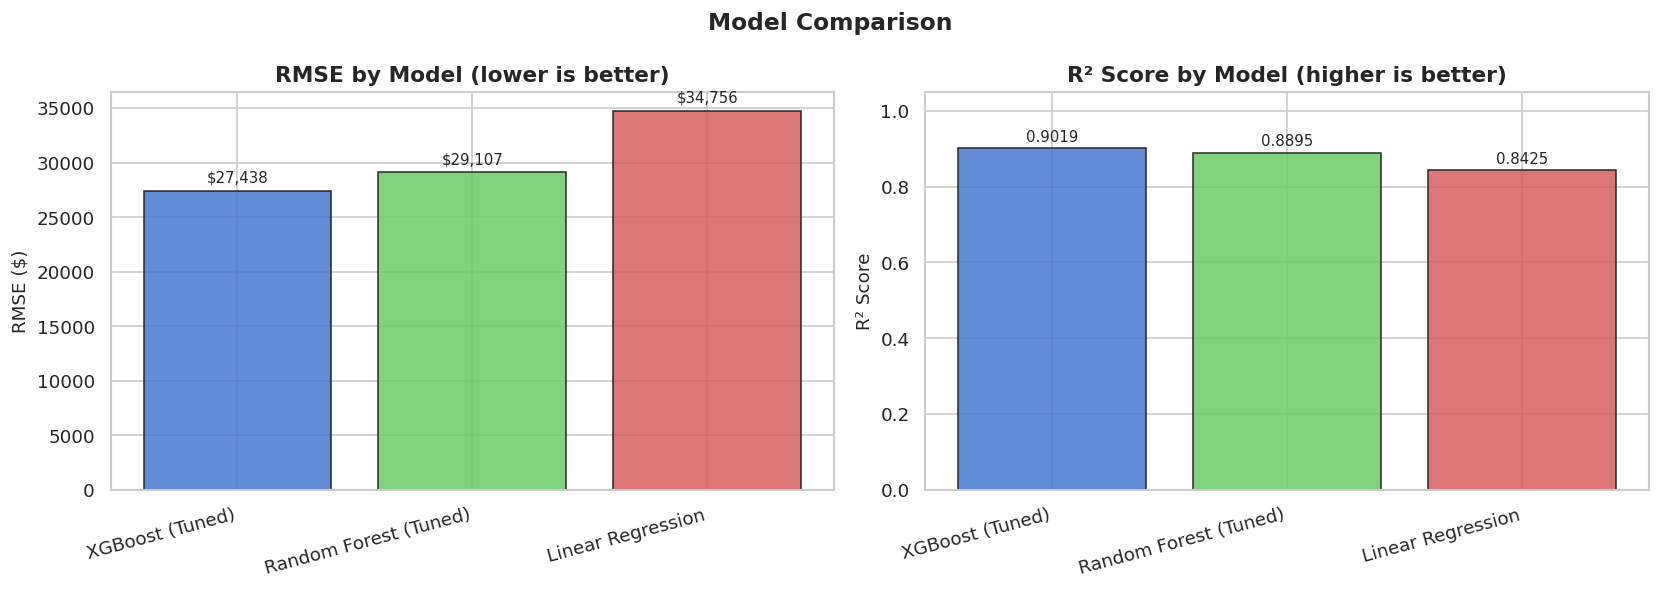

In [28]:
# ── Bar chart: RMSE and R² comparison ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#4878CF', '#6ACC65', '#D65F5F']
models = results_df.index.tolist()

axes[0].bar(models, results_df['RMSE'], color=colors, edgecolor='k', alpha=0.85)
axes[0].set_title('RMSE by Model (lower is better)', fontweight='bold')
axes[0].set_ylabel('RMSE ($)')
axes[0].set_xticklabels(models, rotation=15, ha='right')
for bar, val in zip(axes[0].patches, results_df['RMSE']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f'${val:,.0f}', ha='center', va='bottom', fontsize=9)

axes[1].bar(models, results_df['R2'], color=colors, edgecolor='k', alpha=0.85)
axes[1].set_title('R² Score by Model (higher is better)', fontweight='bold')
axes[1].set_ylabel('R² Score')
axes[1].set_ylim(0, 1.05)
axes[1].set_xticklabels(models, rotation=15, ha='right')
for bar, val in zip(axes[1].patches, results_df['R2']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


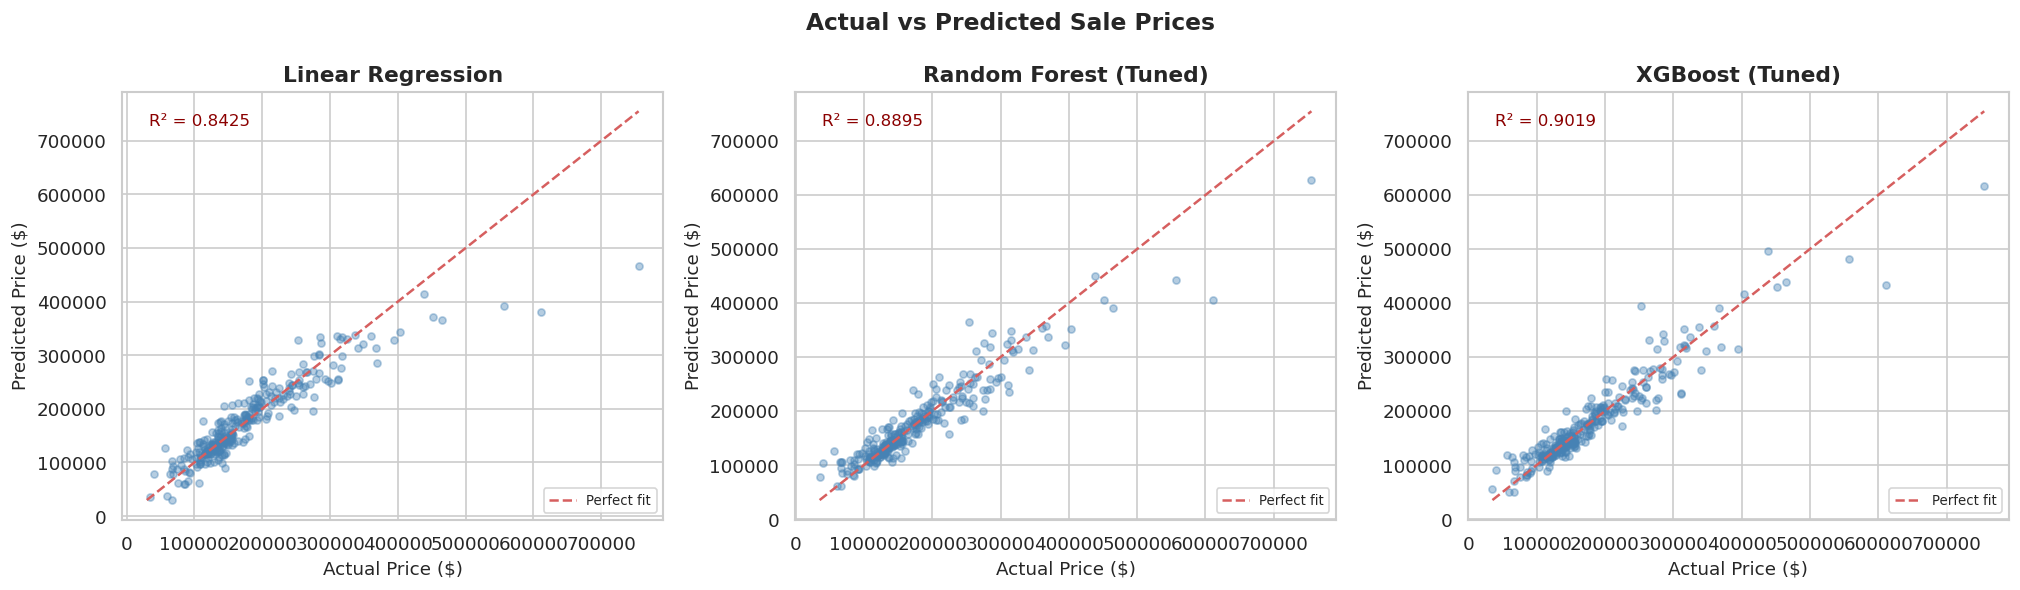

In [29]:
# ── Actual vs Predicted plots ─────────────────────────────────────────
preds = {
    'Linear Regression'   : y_pred_lr,
    'Random Forest (Tuned)': y_pred_rf,
    'XGBoost (Tuned)'     : y_pred_xgb,
}
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, (name, y_pred) in zip(axes, preds.items()):
    ax.scatter(y_test, y_pred, alpha=0.4, s=18, color='steelblue')
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', lw=1.5, label='Perfect fit')
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Actual Price ($)')
    ax.set_ylabel('Predicted Price ($)')
    r2 = r2_score(y_test, y_pred)
    ax.annotate(f'R² = {r2:.4f}', xy=(0.05, 0.92), xycoords='axes fraction',
                fontsize=10, color='darkred')
    ax.legend(fontsize=8)

plt.suptitle('Actual vs Predicted Sale Prices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


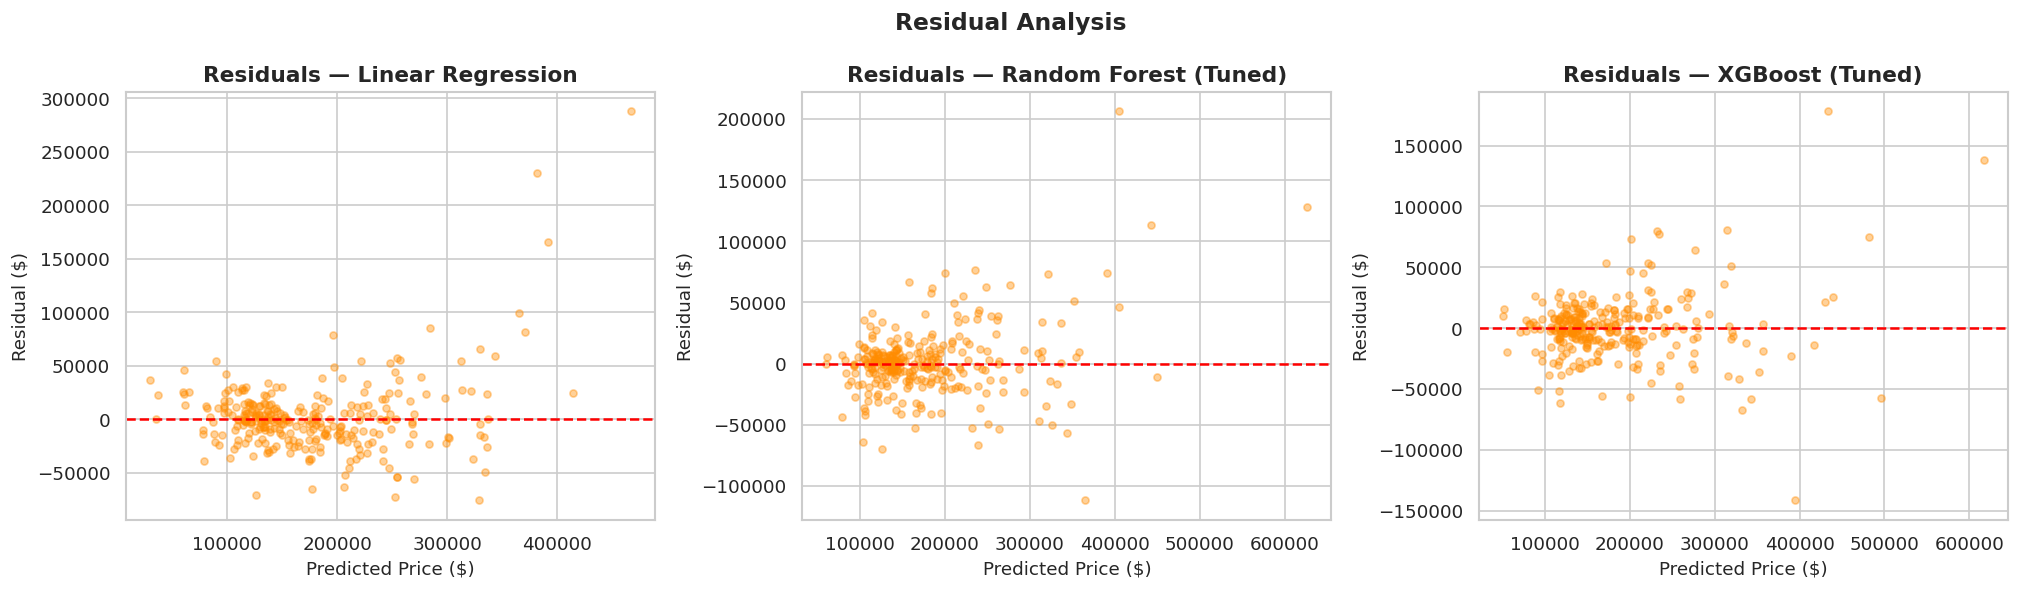

In [30]:
# ── Residual plots ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, (name, y_pred) in zip(axes, preds.items()):
    residuals = y_test - y_pred
    ax.scatter(y_pred, residuals, alpha=0.4, s=18, color='darkorange')
    ax.axhline(0, color='red', linestyle='--', lw=1.5)
    ax.set_title(f'Residuals — {name}', fontweight='bold')
    ax.set_xlabel('Predicted Price ($)')
    ax.set_ylabel('Residual ($)')

plt.suptitle('Residual Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


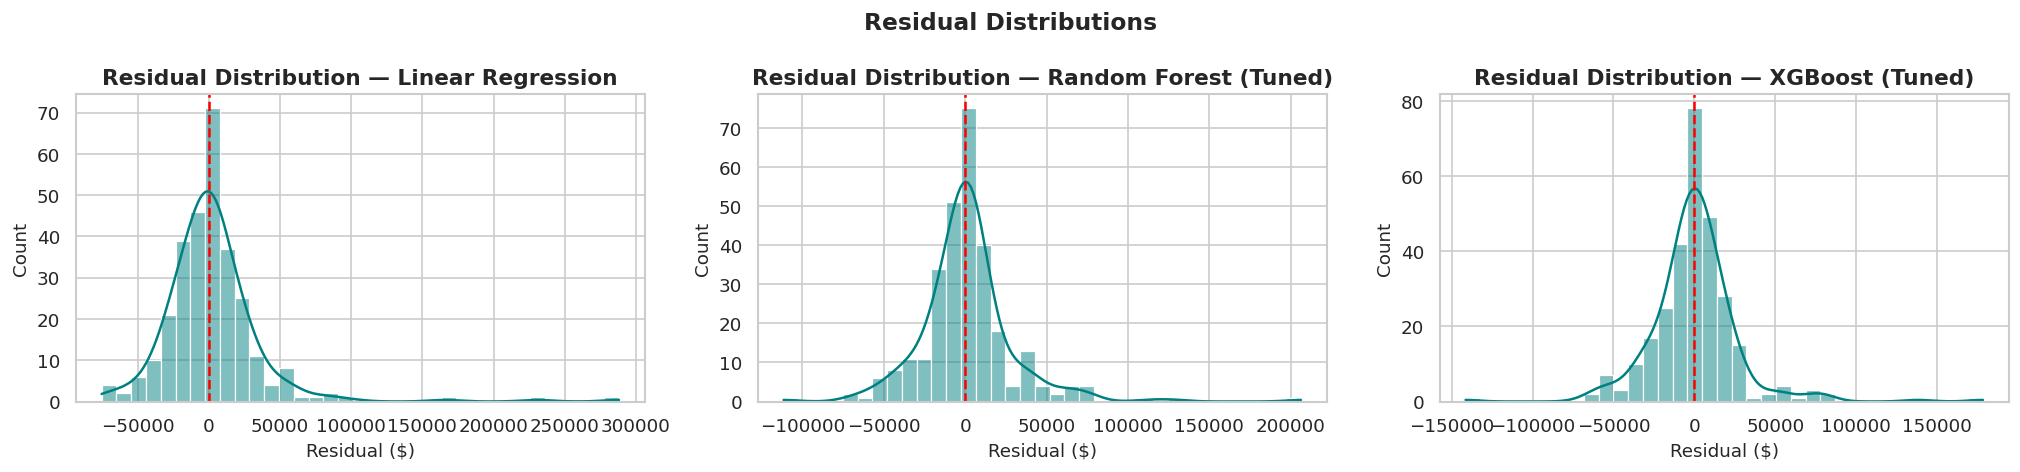

In [31]:
# ── Residual distributions ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 4))

for ax, (name, y_pred) in zip(axes, preds.items()):
    residuals = y_test - y_pred
    sns.histplot(residuals, bins=35, kde=True, ax=ax, color='teal')
    ax.axvline(0, color='red', linestyle='--', lw=1.5)
    ax.set_title(f'Residual Distribution — {name}', fontweight='bold')
    ax.set_xlabel('Residual ($)')

plt.suptitle('Residual Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


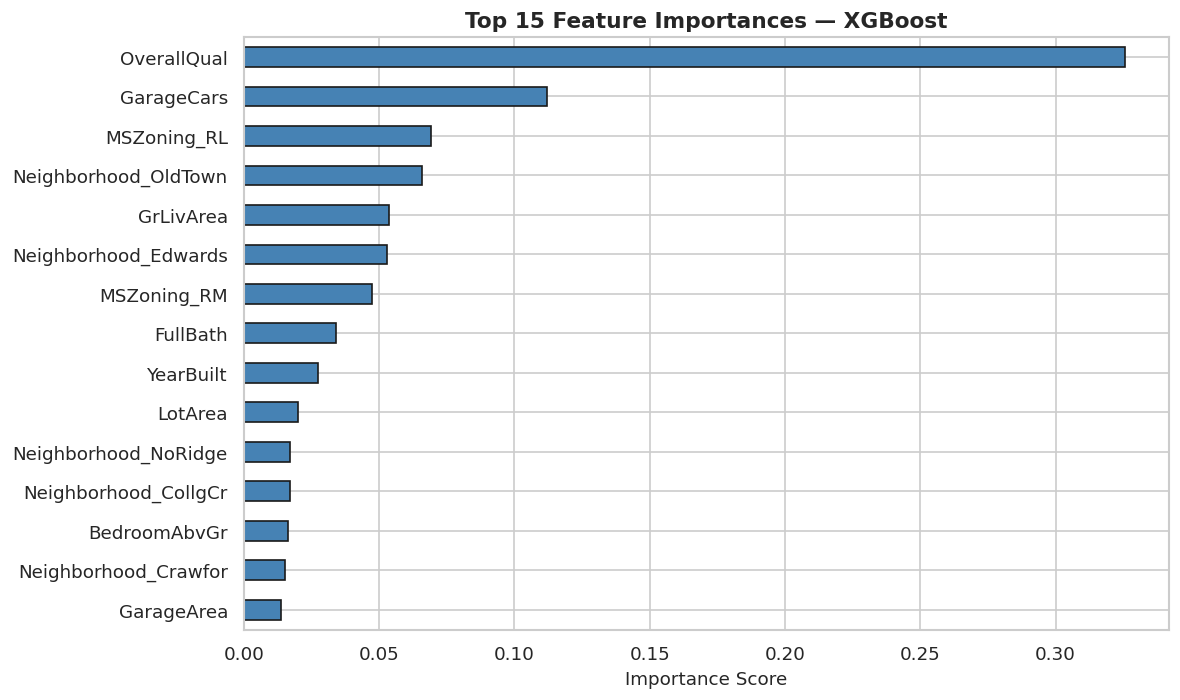

In [32]:
# ── Feature Importance (XGBoost best model) ───────────────────────────
importances = pd.Series(
    xgb_gs.best_estimator_.feature_importances_,
    index=X.columns
).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
importances.sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='k')
ax.set_title('Top 15 Feature Importances — XGBoost', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()


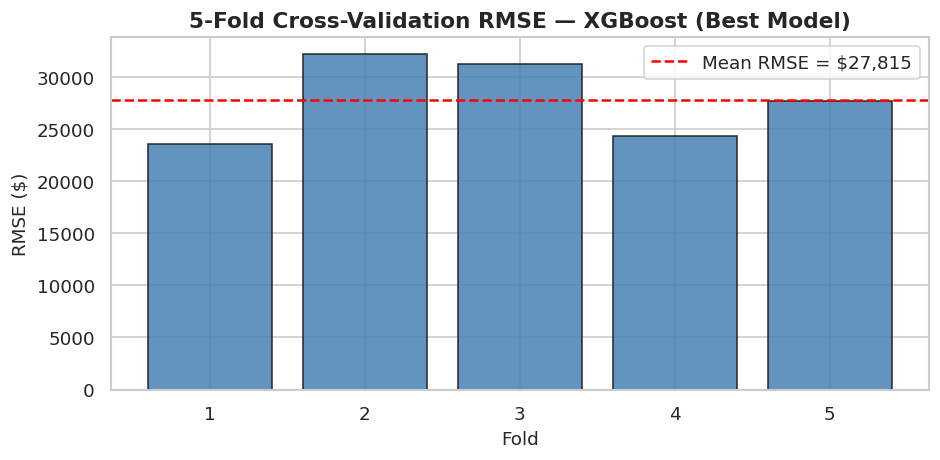

CV RMSE: $27,814.58  ±  $3,491.18


In [33]:
# ── Cross-validation scores (best model) ─────────────────────────────
best_model = xgb_gs.best_estimator_
cv_scores = cross_val_score(best_model, X, y, cv=5,
                            scoring='neg_root_mean_squared_error')
cv_rmse = -cv_scores

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(1, 6), cv_rmse, color='steelblue', edgecolor='k', alpha=0.85)
ax.axhline(cv_rmse.mean(), color='red', linestyle='--', lw=1.5,
           label=f'Mean RMSE = ${cv_rmse.mean():,.0f}')
ax.set_title('5-Fold Cross-Validation RMSE — XGBoost (Best Model)', fontweight='bold')
ax.set_xlabel('Fold')
ax.set_ylabel('RMSE ($)')
ax.set_xticks(range(1, 6))
ax.legend()
plt.tight_layout()
plt.show()

print(f"CV RMSE: ${cv_rmse.mean():,.2f}  ±  ${cv_rmse.std():,.2f}")


---
## 8. Conclusions & Next Steps

### Key Findings
- **XGBoost** achieved the best performance after tuning, with the lowest RMSE and highest R².
- **`OverallQual`** and **`GrLivArea`** are consistently the most influential predictors of sale price.
- Log-transforming `SalePrice` can further improve model performance (residuals become more normally distributed).

### Model Summary
| Model | Relative Performance |
|-------|---------------------|
| Linear Regression | Baseline — interpretable but limited |
| Random Forest (Tuned) | Good — handles non-linearity well |
| XGBoost (Tuned) | **Best** — lowest RMSE, highest R² |

### Potential Improvements
1. **Log-transform the target** `SalePrice` to reduce skew
2. **Add more features** — e.g. `TotalBsmtSF`, `GarageYrBlt`, `Fireplaces`
3. **Stacking / Blending** — combine RF and XGBoost predictions
4. **Advanced imputation** — KNN or MICE for features like `LotFrontage`
5. **Outlier removal** — filter extreme `GrLivArea` outliers that skew regression

---
*Notebook enhanced with markdown documentation, model tuning, and evaluation visuals.*
